# DenseNet121 Transfer Learning for Waste Classification

## Smart Waste Classification System Using Deep Learning

This notebook implements, fine-tunes, and evaluates a DenseNet121 model for
classifying TrashNet waste images into six categories:

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

DenseNet121 is the third pretrained architecture evaluated in this project,
following ResNet50 and EfficientNet-B0.

The experiment uses the same:

- Train, validation, and test split manifest
- Image size
- Data-augmentation policy
- ImageNet normalization
- Class-imbalance strategy
- Training procedure
- Evaluation metrics
- Latency-measurement procedure

Using identical experimental conditions supports a fair and defensible model
comparison.

##  Experiment Objectives

The objectives of this experiment are to:

1. Load DenseNet121 using ImageNet-pretrained weights.
2. Replace the original ImageNet classifier with a six-class TrashNet
   classifier.
3. Train the new classifier while keeping the DenseNet feature extractor
   frozen.
4. Fine-tune selected upper DenseNet layers using a lower learning rate.
5. Preserve the same dataset partitions and preprocessing used by previous
   models.
6. Handle class imbalance using training-derived class weights.
7. Evaluate the final model using:

   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Confusion matrix
   - Per-class accuracy
   - Learning curves

8. Investigate class confusions and high-confidence errors.
9. Measure model size and single-image inference latency.
10. Save the best checkpoint, experiment metadata, and comparison results.

##  DenseNet121 Architecture Overview

DenseNet121 is a convolutional neural network that uses dense connectivity.

In a traditional convolutional network, each layer normally passes its output
only to the next layer. In DenseNet, each layer receives feature maps from all
earlier layers within the same dense block.

Conceptually:

`Layer 1 → Layer 2`

`Layer 1 + Layer 2 → Layer 3`

`Layer 1 + Layer 2 + Layer 3 → Layer 4`

This design encourages:

- Feature reuse
- Strong gradient flow
- Reduced duplication of learned features
- Efficient parameter usage
- Better propagation of low-level and high-level information

DenseNet121 contains:

- An initial convolutional stage
- Four dense blocks
- Transition layers between dense blocks
- Global pooling
- A final fully connected classifier

The original DenseNet121 classifier predicts 1,000 ImageNet categories. It will
be replaced with a new linear layer containing six outputs for TrashNet.

In [1]:
import json
import os
import platform
import random
import sys
import time

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms
from torchvision.models import (
    DenseNet121_Weights,
    densenet121,
)

In [2]:
print("=" * 72)
print("DENSENET121 EXPERIMENT ENVIRONMENT")
print("=" * 72)

print(f"Python executable : {sys.executable}")
print(f"Python version    : {platform.python_version()}")
print(f"PyTorch version   : {torch.__version__}")
print(f"TorchVision       : {torchvision.__version__}")
print(f"Operating system  : {platform.platform()}")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("-" * 72)
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"Selected device   : {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("Hardware note     : CPU-only training environment")

print("=" * 72)

DENSENET121 EXPERIMENT ENVIRONMENT
Python executable : c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\.venv\Scripts\python.exe
Python version    : 3.12.10
PyTorch version   : 2.13.0+cpu
TorchVision       : 0.28.0+cpu
Operating system  : Windows-11-10.0.26200-SP0
------------------------------------------------------------------------
CUDA available    : False
Selected device   : cpu
Hardware note     : CPU-only training environment


In [3]:
SEED = 42


def set_random_seed(seed: int) -> None:
    """
    Configure random generators used by Python, NumPy, and PyTorch.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_random_seed(SEED)

print(f"Random seed configured: {SEED}")

Random seed configured: 42


In [4]:
EXPERIMENT_NAME = "densenet121"
MODEL_VERSION = "1.0.0"

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

BATCH_SIZE = 16
NUM_WORKERS = 0

HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 5

HEAD_LEARNING_RATE = 1e-3
BACKBONE_FINE_TUNE_LEARNING_RATE = 1e-5
CLASSIFIER_FINE_TUNE_LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.30

EARLY_STOPPING_PATIENCE = 5
MINIMUM_IMPROVEMENT = 1e-4

PROJECT_ROOT = Path("..")

DATA_DIRECTORY = PROJECT_ROOT / "data"
SPLITS_DIRECTORY = DATA_DIRECTORY / "splits"

MODEL_DIRECTORY = PROJECT_ROOT / "models"
RESULTS_DIRECTORY = PROJECT_ROOT / "results"
FIGURES_DIRECTORY = RESULTS_DIRECTORY / "figures"
LOGS_DIRECTORY = PROJECT_ROOT / "logs"

MODEL_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LOGS_DIRECTORY.mkdir(parents=True, exist_ok=True)

SPLIT_MANIFEST_PATH = (
    SPLITS_DIRECTORY / "split_manifest.csv"
)

FROZEN_CHECKPOINT_PATH = (
    MODEL_DIRECTORY / "densenet121_frozen_best.pt"
)

FINE_TUNED_CHECKPOINT_PATH = (
    MODEL_DIRECTORY / "densenet121_finetuned_best.pt"
)

print(f"Experiment name : {EXPERIMENT_NAME}")
print(f"Model version   : {MODEL_VERSION}")
print(f"Image size      : {IMAGE_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Device          : {DEVICE}")
print(f"Manifest path   : {SPLIT_MANIFEST_PATH.resolve()}")

Experiment name : densenet121
Model version   : 1.0.0
Image size      : (224, 224)
Batch size      : 16
Device          : cpu
Manifest path   : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits\split_manifest.csv


In [5]:
if not SPLIT_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Split manifest not found: {SPLIT_MANIFEST_PATH.resolve()}"
    )

split_manifest = pd.read_csv(
    SPLIT_MANIFEST_PATH
)

print(
    f"Split manifest loaded successfully: "
    f"{len(split_manifest):,} records"
)

split_manifest.head()

Split manifest loaded successfully: 2,521 records


,class_name,split,source_path,destination_path,sha256
0,cardboard,train,data\raw\trashnet\cardboard\cardboard235.jpg,data\processed\train\cardboard\cardboard235.jpg,d550d9d6c2b831d3dee5bb985a259a4f872df22baaf2a1...
1,cardboard,train,data\raw\trashnet\cardboard\cardboard213.jpg,data\processed\train\cardboard\cardboard213.jpg,b3c979a3f4b7246548b51ee34782dfab7e146a569511f6...
2,cardboard,train,data\raw\trashnet\cardboard\cardboard169.jpg,data\processed\train\cardboard\cardboard169.jpg,a6b0a3670259dd8027b06e87ae292e8eca1c87634d785e...
3,cardboard,train,data\raw\trashnet\cardboard\cardboard138.jpg,data\processed\train\cardboard\cardboard138.jpg,7d70edc60cfb2c34a6c9d636200d39f61b0c5d7ed4a69b...
4,cardboard,train,data\raw\trashnet\cardboard\cardboard334.jpg,data\processed\train\cardboard\cardboard334.jpg,e20217c46a83b281bcda09e3d2679e22292d3e3c25bc93...


In [7]:
PATH_COLUMN = "destination_path"
CLASS_COLUMN = "class_name"
SPLIT_COLUMN = "split"

required_manifest_columns = {
    PATH_COLUMN,
    CLASS_COLUMN,
    SPLIT_COLUMN,
    "sha256",
}

missing_manifest_columns = (
    required_manifest_columns
    - set(split_manifest.columns)
)

if missing_manifest_columns:
    raise KeyError(
        "The manifest is missing required columns: "
        + ", ".join(sorted(missing_manifest_columns))
    )

print("Required manifest columns verified.")
PATH_COLUMN = "destination_path"
CLASS_COLUMN = "class_name"
SPLIT_COLUMN = "split"

required_manifest_columns = {
    PATH_COLUMN,
    CLASS_COLUMN,
    SPLIT_COLUMN,
    "sha256",
}

missing_manifest_columns = (
    required_manifest_columns
    - set(split_manifest.columns)
)

if missing_manifest_columns:
    raise KeyError(
        "The manifest is missing required columns: "
        + ", ".join(sorted(missing_manifest_columns))
    )

print("Required manifest columns verified.")

Required manifest columns verified.
Required manifest columns verified.


In [8]:
def resolve_image_path(
    stored_path: str,
    project_root: Path,
) -> Path:
    """
    Resolve an absolute or project-relative manifest image path.
    """
    image_path = Path(stored_path)

    if image_path.is_absolute():
        return image_path

    return (project_root / image_path).resolve()


split_manifest = split_manifest.copy()

split_manifest["resolved_path"] = (
    split_manifest[PATH_COLUMN]
    .apply(
        lambda stored_path: resolve_image_path(
            stored_path=stored_path,
            project_root=PROJECT_ROOT,
        )
    )
)

split_manifest["file_exists"] = (
    split_manifest["resolved_path"]
    .apply(Path.exists)
)

missing_image_records = split_manifest[
    split_manifest["file_exists"] == False
]

if not missing_image_records.empty:
    display(
        missing_image_records[
            [
                CLASS_COLUMN,
                SPLIT_COLUMN,
                PATH_COLUMN,
                "resolved_path",
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_image_records)} manifest images "
        "could not be found."
    )

print(
    f"All {len(split_manifest):,} image paths "
    "were resolved successfully."
)

All 2,521 image paths were resolved successfully.


In [9]:
hash_split_counts = (
    split_manifest
    .groupby("sha256")[SPLIT_COLUMN]
    .nunique()
)

cross_split_hashes = hash_split_counts[
    hash_split_counts > 1
]

if len(cross_split_hashes) > 0:
    raise ValueError(
        "Data leakage detected: identical image content "
        "appears in multiple splits."
    )

print(
    "No duplicate image content was found "
    "across train, validation, and test splits."
)

No duplicate image content was found across train, validation, and test splits.


In [10]:
hash_class_counts = (
    split_manifest
    .groupby("sha256")[CLASS_COLUMN]
    .nunique()
)

conflicting_label_hashes = hash_class_counts[
    hash_class_counts > 1
]

if len(conflicting_label_hashes) > 0:
    raise ValueError(
        "Identical image content has conflicting class labels."
    )

print("No conflicting labels were detected.")

No conflicting labels were detected.


In [11]:
class_names = sorted(
    split_manifest[CLASS_COLUMN]
    .unique()
    .tolist()
)

class_to_index = {
    class_name: class_index
    for class_index, class_name
    in enumerate(class_names)
}

index_to_class = {
    class_index: class_name
    for class_name, class_index
    in class_to_index.items()
}

NUM_CLASSES = len(class_names)

split_manifest["class_index"] = (
    split_manifest[CLASS_COLUMN]
    .map(class_to_index)
    .astype(int)
)

print(f"Number of classes: {NUM_CLASSES}")

for class_name, class_index in class_to_index.items():
    print(f"{class_index}: {class_name}")

Number of classes: 6
0: cardboard
1: glass
2: metal
3: paper
4: plastic
5: trash


In [12]:
train_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Training images   : {len(train_manifest):,}")
print(f"Validation images : {len(validation_manifest):,}")
print(f"Test images       : {len(test_manifest):,}")

Training images   : 1,762
Validation images : 378
Test images       : 381


In [13]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STANDARD_DEVIATION = [
    0.229,
    0.224,
    0.225,
]

training_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            size=IMAGE_SIZE,
            scale=(0.80, 1.00),
            ratio=(0.90, 1.10),
        ),
        transforms.RandomHorizontalFlip(
            p=0.50,
        ),
        transforms.RandomRotation(
            degrees=10,
        ),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STANDARD_DEVIATION,
        ),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STANDARD_DEVIATION,
        ),
    ]
)

print("DenseNet121 transforms configured.")

DenseNet121 transforms configured.


In [14]:
class WasteClassificationDataset(Dataset):
    """
    Manifest-based dataset for TrashNet classification.
    """

    def __init__(
        self,
        manifest: pd.DataFrame,
        transform=None,
    ) -> None:
        self.manifest = (
            manifest.copy()
            .reset_index(drop=True)
        )

        self.transform = transform

        required_columns = {
            "resolved_path",
            "class_index",
        }

        missing_columns = (
            required_columns
            - set(self.manifest.columns)
        )

        if missing_columns:
            raise ValueError(
                "Dataset manifest is missing columns: "
                + ", ".join(sorted(missing_columns))
            )

    def __len__(self) -> int:
        return len(self.manifest)

    def __getitem__(self, index: int) -> dict:
        record = self.manifest.iloc[index]

        image_path = Path(
            record["resolved_path"]
        )

        class_index = int(
            record["class_index"]
        )

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")

        except (
            FileNotFoundError,
            UnidentifiedImageError,
            OSError,
        ) as error:
            raise RuntimeError(
                f"Unable to load image: {image_path}"
            ) from error

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": class_index,
            "path": str(image_path),
        }

In [15]:
train_dataset = WasteClassificationDataset(
    manifest=train_manifest,
    transform=training_transform,
)

validation_dataset = WasteClassificationDataset(
    manifest=validation_manifest,
    transform=evaluation_transform,
)

test_dataset = WasteClassificationDataset(
    manifest=test_manifest,
    transform=evaluation_transform,
)

data_loader_generator = torch.Generator()
data_loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    generator=data_loader_generator,
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(validation_loader)}")
print(f"Test batches       : {len(test_loader)}")

Training batches   : 111
Validation batches : 24
Test batches       : 24


In [16]:
sample_batch = next(
    iter(train_loader)
)

sample_images = sample_batch["image"]
sample_labels = sample_batch["label"]
sample_paths = sample_batch["path"]

print(f"Image batch shape : {sample_images.shape}")
print(f"Label batch shape : {sample_labels.shape}")
print(f"Image dtype       : {sample_images.dtype}")
print(f"Label dtype       : {sample_labels.dtype}")
print(f"First class       : {index_to_class[int(sample_labels[0])]}")
print(f"First path        : {sample_paths[0]}")

Image batch shape : torch.Size([16, 3, 224, 224])
Label batch shape : torch.Size([16])
Image dtype       : torch.float32
Label dtype       : torch.int64
First class       : plastic
First path        : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\train\plastic\plastic379.jpg


In [17]:
training_class_counts = (
    train_manifest[CLASS_COLUMN]
    .value_counts()
    .reindex(class_names)
)

total_training_samples = len(
    train_manifest
)

class_weights_array = (
    total_training_samples
    / (
        NUM_CLASSES
        * training_class_counts.values
    )
)

class_weights = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
    device=DEVICE,
)

class_weight_table = pd.DataFrame(
    {
        "class_name": class_names,
        "training_samples": (
            training_class_counts.values
        ),
        "class_weight": (
            class_weights_array
        ),
    }
)

class_weight_table

,class_name,training_samples,class_weight
0,cardboard,282,1.041371
1,glass,348,0.843870
2,metal,286,1.026807
3,paper,415,0.707631
4,plastic,336,0.874008
5,trash,95,3.091228


In [18]:
DENSENET_WEIGHTS = (
    DenseNet121_Weights.DEFAULT
)

densenet_model = densenet121(
    weights=DENSENET_WEIGHTS
)

print("DenseNet121 loaded successfully.")
print("\nOriginal classifier:")
print(densenet_model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Mudassar Iqbal Shah/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100.0%


DenseNet121 loaded successfully.

Original classifier:
Linear(in_features=1024, out_features=1000, bias=True)


In [19]:
for parameter in (
    densenet_model.features.parameters()
):
    parameter.requires_grad = False

print("DenseNet121 feature extractor frozen.")

DenseNet121 feature extractor frozen.


In [20]:
classifier_input_features = (
    densenet_model.classifier.in_features
)

densenet_model.classifier = nn.Sequential(
    nn.Dropout(
        p=DROPOUT_RATE,
    ),
    nn.Linear(
        in_features=classifier_input_features,
        out_features=NUM_CLASSES,
    ),
)

densenet_model = densenet_model.to(
    DEVICE
)

print("Updated TrashNet classifier:")
print(densenet_model.classifier)

Updated TrashNet classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=6, bias=True)
)


In [21]:
def count_model_parameters(
    model: nn.Module,
) -> dict:
    """
    Count total, trainable, and frozen parameters.
    """
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    frozen_parameters = (
        total_parameters
        - trainable_parameters
    )

    return {
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "frozen_parameters": frozen_parameters,
    }


frozen_parameter_summary = (
    count_model_parameters(
        densenet_model
    )
)

for key, value in frozen_parameter_summary.items():
    print(f"{key}: {value:,}")

total_parameters: 6,960,006
trainable_parameters: 6,150
frozen_parameters: 6,953,856


In [22]:
densenet_model.eval()

smoke_test_batch = next(
    iter(train_loader)
)

smoke_test_images = (
    smoke_test_batch["image"]
    .to(DEVICE)
)

smoke_test_labels = (
    smoke_test_batch["label"]
    .to(DEVICE)
)

with torch.inference_mode():
    smoke_test_logits = densenet_model(
        smoke_test_images
    )

print(
    "Input shape :",
    smoke_test_images.shape,
)

print(
    "Output shape:",
    smoke_test_logits.shape,
)

Input shape : torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 6])


In [23]:
expected_output_shape = (
    smoke_test_images.shape[0],
    NUM_CLASSES,
)

if tuple(smoke_test_logits.shape) != expected_output_shape:
    raise ValueError(
        f"Expected output shape {expected_output_shape}, "
        f"received {tuple(smoke_test_logits.shape)}."
    )

if not torch.isfinite(
    smoke_test_logits
).all():
    raise ValueError(
        "DenseNet121 produced non-finite logits."
    )

print("DenseNet121 forward-pass smoke test passed.")

DenseNet121 forward-pass smoke test passed.


In [24]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

trainable_parameters = [
    parameter
    for parameter in densenet_model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    params=trainable_parameters,
    lr=HEAD_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

print("DenseNet121 frozen-stage optimization configured.")

DenseNet121 frozen-stage optimization configured.


In [25]:
smoke_test_loss = criterion(
    smoke_test_logits,
    smoke_test_labels,
)

print(
    f"Smoke-test weighted loss: "
    f"{smoke_test_loss.item():.4f}"
)

if not torch.isfinite(
    smoke_test_loss
):
    raise ValueError(
        "DenseNet121 smoke-test loss is not finite."
    )

Smoke-test weighted loss: 1.9490


In [27]:
def calculate_correct_predictions(
    logits: torch.Tensor,
    labels: torch.Tensor,
) -> int:
    """
    Count correct predictions for a single batch.
    """
    predicted_labels = torch.argmax(
        logits,
        dim=1,
    )

    return int(
        (predicted_labels == labels)
        .sum()
        .item()
    )

In [28]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    keep_batch_norm_frozen: bool = False,
) -> dict:
    """
    Train a model for one complete epoch.
    """
    model.train()

    if keep_batch_norm_frozen:
        for module in model.modules():
            if isinstance(
                module,
                (
                    nn.BatchNorm1d,
                    nn.BatchNorm2d,
                    nn.BatchNorm3d,
                ),
            ):
                module.eval()

    running_loss = 0.0
    correct_predictions = 0
    processed_samples = 0

    for batch in data_loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = batch["label"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = loss_function(
            logits,
            labels,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "A non-finite training loss was encountered."
            )

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        correct_predictions += (
            calculate_correct_predictions(
                logits,
                labels,
            )
        )

        processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "The training DataLoader returned no samples."
        )

    return {
        "loss": float(
            running_loss / processed_samples
        ),
        "accuracy": float(
            correct_predictions / processed_samples
        ),
        "correct_predictions": int(
            correct_predictions
        ),
        "sample_count": int(
            processed_samples
        ),
    }

In [87]:
def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict:
    """
    Evaluate a PyTorch classification model for one complete epoch.

    Parameters
    ----------
    model:
        Model being evaluated.

    data_loader:
        Validation or test DataLoader.

    loss_function:
        Loss function used to calculate average loss.

    device:
        CPU or CUDA device.

    Returns
    -------
    dict
        Dictionary containing average loss, accuracy,
        number of correct predictions, and sample count.
    """
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    processed_samples = 0

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "A non-finite validation loss was encountered."
                )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            correct_predictions += (
                calculate_correct_predictions(
                    logits,
                    labels,
                )
            )

            processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "The validation DataLoader returned no samples."
        )

    average_loss = (
        running_loss / processed_samples
    )

    accuracy = (
        correct_predictions / processed_samples
    )

    return {
        "loss": float(average_loss),
        "accuracy": float(accuracy),
        "correct_predictions": int(
            correct_predictions
        ),
        "sample_count": int(
            processed_samples
        ),
    }

##  Model Checkpointing

The best model is selected using validation loss.

A checkpoint stores:

- Model weights
- Optimizer state
- Epoch number
- Validation loss
- Validation accuracy
- Architecture
- Model version
- Training stage
- Class mapping
- Input image size
- Framework versions

This metadata will later support production inference and the `/model-info`
API endpoint.

In [29]:
def save_densenet_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    validation_loss: float,
    validation_accuracy: float,
    training_stage: str,
) -> None:
    """
    Save DenseNet121 model weights and experiment metadata.
    """
    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint = {
        "architecture": "densenet121",
        "model_version": MODEL_VERSION,
        "training_stage": training_stage,
        "epoch": int(epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "validation_loss": float(
            validation_loss
        ),
        "validation_accuracy": float(
            validation_accuracy
        ),
        "number_of_classes": NUM_CLASSES,
        "class_names": list(class_names),
        "class_to_index": dict(
            class_to_index
        ),
        "image_size": list(IMAGE_SIZE),
        "dropout_rate": float(
            DROPOUT_RATE
        ),
        "saved_at": datetime.now().isoformat(),
        "pytorch_version": torch.__version__,
        "torchvision_version": (
            torchvision.__version__
        ),
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

In [33]:
def run_training_stage(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    device: torch.device,
    maximum_epochs: int,
    checkpoint_path: Path,
    training_stage: str,
    early_stopping_patience: int,
    minimum_improvement: float,
    keep_batch_norm_frozen: bool = False,
) -> pd.DataFrame:
    """
    Run one complete DenseNet121 training stage.
    """
    history_records = []

    best_validation_loss = float("inf")
    non_improving_epochs = 0

    stage_start_time = time.perf_counter()

    for epoch_index in range(
        maximum_epochs
    ):
        epoch_number = epoch_index + 1
        epoch_start_time = time.perf_counter()

        learning_rates = [
            parameter_group["lr"]
            for parameter_group
            in optimizer.param_groups
        ]

        training_metrics = train_one_epoch(
            model=model,
            data_loader=train_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            device=device,
            keep_batch_norm_frozen=(
                keep_batch_norm_frozen
            ),
        )

        validation_metrics = (
            validate_one_epoch(
                model=model,
                data_loader=validation_loader,
                loss_function=loss_function,
                device=device,
            )
        )

        scheduler.step(
            validation_metrics["loss"]
        )

        validation_improved = (
            validation_metrics["loss"]
            < (
                best_validation_loss
                - minimum_improvement
            )
        )

        if validation_improved:
            best_validation_loss = (
                validation_metrics["loss"]
            )

            non_improving_epochs = 0

            save_densenet_checkpoint(
                checkpoint_path=checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch_number,
                validation_loss=(
                    validation_metrics["loss"]
                ),
                validation_accuracy=(
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                training_stage=training_stage,
            )

            checkpoint_status = (
                "Best checkpoint saved"
            )

        else:
            non_improving_epochs += 1
            checkpoint_status = (
                "No validation improvement"
            )

        epoch_duration_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        history_records.append(
            {
                "epoch": epoch_number,
                "learning_rates": ",".join(
                    f"{rate:.10f}"
                    for rate in learning_rates
                ),
                "train_loss": (
                    training_metrics["loss"]
                ),
                "train_accuracy": (
                    training_metrics[
                        "accuracy"
                    ]
                ),
                "validation_loss": (
                    validation_metrics["loss"]
                ),
                "validation_accuracy": (
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                "epoch_duration_seconds": (
                    epoch_duration_seconds
                ),
                "checkpoint_saved": bool(
                    validation_improved
                ),
            }
        )

        print("=" * 80)
        print(
            f"{training_stage.replace('_', ' ').title()} "
            f"— Epoch {epoch_number}/{maximum_epochs}"
        )

        print(
            "Learning rates      :",
            ", ".join(
                f"{rate:.8f}"
                for rate in learning_rates
            ),
        )

        print(
            f"Training loss       : "
            f"{training_metrics['loss']:.4f}"
        )

        print(
            f"Training accuracy   : "
            f"{training_metrics['accuracy']:.4f}"
        )

        print(
            f"Validation loss     : "
            f"{validation_metrics['loss']:.4f}"
        )

        print(
            f"Validation accuracy : "
            f"{validation_metrics['accuracy']:.4f}"
        )

        print(
            f"Epoch duration      : "
            f"{epoch_duration_seconds:.2f} seconds"
        )

        print(
            f"Checkpoint status   : "
            f"{checkpoint_status}"
        )

        print(
            f"Early-stop counter  : "
            f"{non_improving_epochs}/"
            f"{early_stopping_patience}"
        )

        if (
            non_improving_epochs
            >= early_stopping_patience
        ):
            print("=" * 80)
            print(
                "Early stopping activated."
            )
            break

    total_duration_seconds = (
        time.perf_counter()
        - stage_start_time
    )

    print("=" * 80)
    print(
        f"{training_stage.replace('_', ' ').title()} "
        "completed."
    )

    print(
        f"Total duration: "
        f"{total_duration_seconds / 60:.2f} minutes"
    )

    print(
        f"Best validation loss: "
        f"{best_validation_loss:.4f}"
    )

    return pd.DataFrame(
        history_records
    )

##  Frozen-Stage Pipeline Test

A one-epoch smoke test is performed before official training.

The test confirms that:

- Training completes
- Validation completes
- Metrics are recorded
- A checkpoint is created
- CPU execution is stable

Because this test updates classifier weights, the model will be reconstructed
before official training.

In [36]:
FROZEN_SMOKE_TEST_PATH = (
    MODEL_DIRECTORY
    / "densenet121_frozen_smoke_test.pt"
)

frozen_smoke_history = run_training_stage(
    model=densenet_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_function=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    maximum_epochs=1,
    checkpoint_path=(
        FROZEN_SMOKE_TEST_PATH
    ),
    training_stage=(
        "frozen_feature_extraction_smoke_test"
    ),
    early_stopping_patience=1,
    minimum_improvement=(
        MINIMUM_IMPROVEMENT
    ),
    keep_batch_norm_frozen=False,
)

frozen_smoke_history

Frozen Feature Extraction Smoke Test — Epoch 1/1
Learning rates      : 0.00100000
Training loss       : 1.0274
Training accuracy   : 0.6356
Validation loss     : 0.8675
Validation accuracy : 0.7143
Epoch duration      : 314.23 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/1
Frozen Feature Extraction Smoke Test completed.
Total duration: 5.24 minutes
Best validation loss: 0.8675


,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,0.0010000000,1.027361,0.635641,0.867467,0.714286,314.233204,True


In [91]:
set_random_seed(SEED)

densenet_model = densenet121(
    weights=DENSENET_WEIGHTS
)

for parameter in densenet_model.features.parameters():
    parameter.requires_grad = False

classifier_input_features = (
    densenet_model.classifier.in_features
)

densenet_model.classifier = nn.Sequential(
    nn.Dropout(
        p=DROPOUT_RATE,
    ),
    nn.Linear(
        in_features=classifier_input_features,
        out_features=NUM_CLASSES,
    ),
)

densenet_model = densenet_model.to(
    DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

trainable_parameters = [
    parameter
    for parameter in densenet_model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    params=trainable_parameters,
    lr=HEAD_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

print(
    "DenseNet121 was reinitialized for "
    "the official frozen-stage experiment."
)

DenseNet121 was reinitialized for the official frozen-stage experiment.


In [38]:
frozen_training_history = (
    run_training_stage(
        model=densenet_model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        loss_function=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        maximum_epochs=HEAD_EPOCHS,
        checkpoint_path=(
            FROZEN_CHECKPOINT_PATH
        ),
        training_stage=(
            "frozen_feature_extraction"
        ),
        early_stopping_patience=(
            EARLY_STOPPING_PATIENCE
        ),
        minimum_improvement=(
            MINIMUM_IMPROVEMENT
        ),
        keep_batch_norm_frozen=False,
    )
)

frozen_training_history

Frozen Feature Extraction — Epoch 1/10
Learning rates      : 0.00100000
Training loss       : 0.9007
Training accuracy   : 0.6952
Validation loss     : 0.8282
Validation accuracy : 0.7037
Epoch duration      : 436.76 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Frozen Feature Extraction — Epoch 2/10
Learning rates      : 0.00100000
Training loss       : 0.8279
Training accuracy   : 0.7072
Validation loss     : 0.6770
Validation accuracy : 0.7831
Epoch duration      : 400.76 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Frozen Feature Extraction — Epoch 3/10
Learning rates      : 0.00100000
Training loss       : 0.7957
Training accuracy   : 0.7174
Validation loss     : 0.6761
Validation accuracy : 0.7672
Epoch duration      : 430.82 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Frozen Feature Extraction — Epoch 4/10
Learning rates      : 0.00100000
Training loss       : 0.7569
Training accur

,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,0.0010000000,0.900686,0.695233,0.828230,0.703704,436.756497,True
1,2,0.0010000000,0.827886,0.707151,0.677004,0.783069,400.764725,True
2,3,0.0010000000,0.795724,0.717367,0.676064,0.767196,430.815134,True
3,4,0.0010000000,0.756914,0.727015,0.638835,0.809524,451.099271,True
4,5,0.0010000000,0.750352,0.735528,0.636957,0.767196,449.846109,True
5,6,0.0010000000,0.716630,0.733825,0.604381,0.801587,429.113950,True
6,7,0.0010000000,0.703443,0.747446,0.583366,0.806878,523.336805,True
7,8,0.0010000000,0.672049,0.758797,0.595236,0.801587,412.966829,False
8,9,0.0010000000,0.694661,0.757662,0.599525,0.812169,429.177849,False
9,10,0.0010000000,0.681893,0.750284,0.578359,0.830688,411.376655,True


In [39]:
FROZEN_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "densenet121_frozen_history.csv"
)

frozen_training_history.to_csv(
    FROZEN_HISTORY_PATH,
    index=False,
)

print(FROZEN_HISTORY_PATH.resolve())


C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\logs\densenet121_frozen_history.csv


In [40]:
def plot_training_curves(
    history: pd.DataFrame,
    title_prefix: str,
    file_prefix: str,
) -> tuple:
    """
    Plot and save accuracy and loss curves.
    """
    FIGURES_DIRECTORY.mkdir(
        parents=True,
        exist_ok=True,
    )

    accuracy_path = (
        FIGURES_DIRECTORY
        / f"{file_prefix}_accuracy.png"
    )

    loss_path = (
        FIGURES_DIRECTORY
        / f"{file_prefix}_loss.png"
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        history["epoch"],
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy",
    )

    plt.plot(
        history["epoch"],
        history["validation_accuracy"],
        marker="o",
        label="Validation Accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.figure(figsize=(9, 6))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label="Training Loss",
    )

    plt.plot(
        history["epoch"],
        history["validation_loss"],
        marker="o",
        label="Validation Loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Weighted Cross-Entropy Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return accuracy_path, loss_path

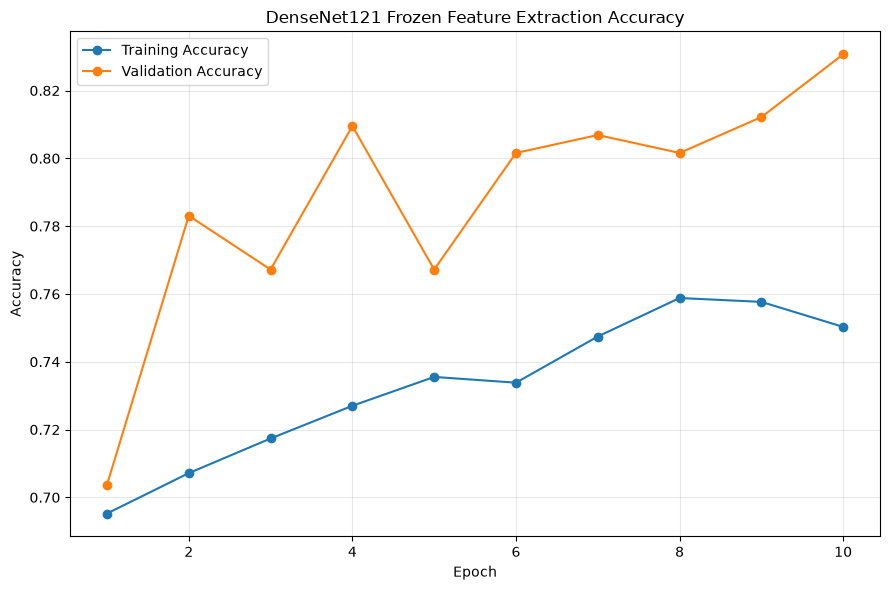

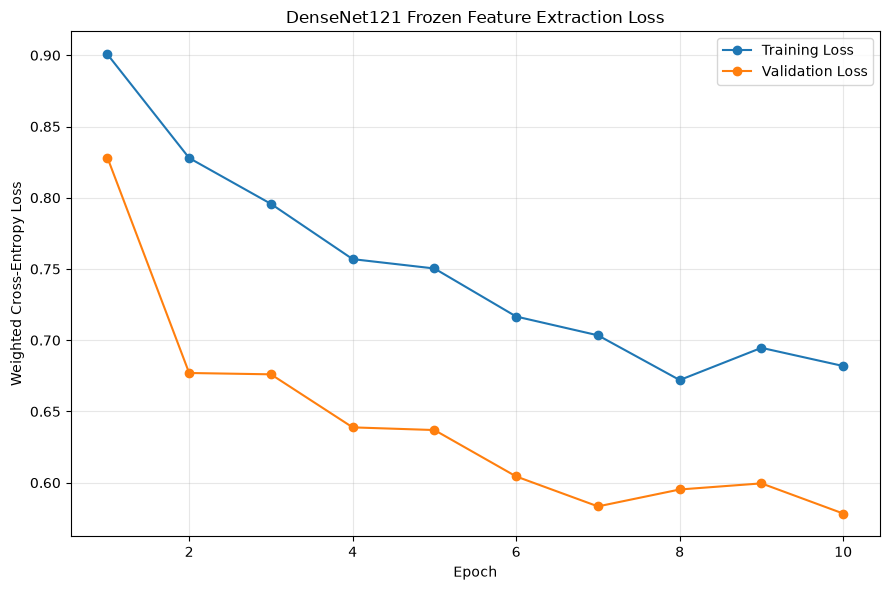

In [41]:
(
    FROZEN_ACCURACY_FIGURE_PATH,
    FROZEN_LOSS_FIGURE_PATH,
) = plot_training_curves(
    history=frozen_training_history,
    title_prefix=(
        "DenseNet121 Frozen Feature Extraction"
    ),
    file_prefix=(
        "densenet121_frozen"
    ),
)

In [42]:
best_frozen_row = (
    frozen_training_history.loc[
        frozen_training_history[
            "validation_loss"
        ].idxmin()
    ]
)

best_frozen_epoch = int(
    best_frozen_row["epoch"]
)

best_frozen_validation_loss = float(
    best_frozen_row[
        "validation_loss"
    ]
)

best_frozen_validation_accuracy = float(
    best_frozen_row[
        "validation_accuracy"
    ]
)

print(
    f"Best frozen epoch: "
    f"{best_frozen_epoch}"
)

print(
    f"Best frozen validation loss: "
    f"{best_frozen_validation_loss:.4f}"
)

print(
    f"Best frozen validation accuracy: "
    f"{best_frozen_validation_accuracy:.4f}"
)

Best frozen epoch: 10
Best frozen validation loss: 0.5784
Best frozen validation accuracy: 0.8307


In [43]:
frozen_checkpoint = torch.load(
    FROZEN_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

densenet_model.load_state_dict(
    frozen_checkpoint[
        "model_state_dict"
    ]
)

densenet_model = densenet_model.to(
    DEVICE
)

print(
    "Best frozen DenseNet121 checkpoint restored."
)

Best frozen DenseNet121 checkpoint restored.


In [44]:
for parameter in densenet_model.parameters():
    parameter.requires_grad = False

for parameter in (
    densenet_model.classifier.parameters()
):
    parameter.requires_grad = True

for parameter in (
    densenet_model.features.denseblock4.parameters()
):
    parameter.requires_grad = True

for parameter in (
    densenet_model.features.norm5.parameters()
):
    parameter.requires_grad = True

In [45]:
batch_norm_count = 0

for module in densenet_model.modules():
    if isinstance(
        module,
        (
            nn.BatchNorm1d,
            nn.BatchNorm2d,
            nn.BatchNorm3d,
        ),
    ):
        batch_norm_count += 1

        for parameter in module.parameters():
            parameter.requires_grad = False

print(
    f"Frozen Batch Normalization modules: "
    f"{batch_norm_count}"
)

Frozen Batch Normalization modules: 121


In [46]:
fine_tuning_parameter_summary = (
    count_model_parameters(
        densenet_model
    )
)

for key, value in (
    fine_tuning_parameter_summary.items()
):
    print(
        f"{key}: {value:,}"
    )

total_parameters: 6,960,006
trainable_parameters: 2,136,070
frozen_parameters: 4,823,936


In [47]:
feature_trainability_records = []

for module_name, module in (
    densenet_model.features.named_children()
):
    total_parameters = sum(
        parameter.numel()
        for parameter in module.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in module.parameters()
        if parameter.requires_grad
    )

    feature_trainability_records.append(
        {
            "module": module_name,
            "total_parameters": total_parameters,
            "trainable_parameters": (
                trainable_parameters
            ),
            "contains_trainable_parameters": (
                trainable_parameters > 0
            ),
        }
    )

pd.DataFrame(
    feature_trainability_records
)

,module,total_parameters,trainable_parameters,contains_trainable_parameters
0,conv0,9408,0,False
1,norm0,128,0,False
2,relu0,0,0,False
3,pool0,0,0,False
4,denseblock1,335040,0,False
5,transition1,33280,0,False
6,denseblock2,919680,0,False
7,transition2,132096,0,False
8,denseblock3,2837760,0,False
9,transition3,526336,0,False


In [48]:
trainable_backbone_parameters = [
    parameter
    for parameter
    in densenet_model.features.parameters()
    if parameter.requires_grad
]

trainable_classifier_parameters = [
    parameter
    for parameter
    in densenet_model.classifier.parameters()
    if parameter.requires_grad
]

if not trainable_backbone_parameters:
    raise RuntimeError(
        "No trainable DenseNet backbone parameters were found."
    )

if not trainable_classifier_parameters:
    raise RuntimeError(
        "No trainable classifier parameters were found."
    )

fine_tuning_criterion = (
    nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE)
    )
)

fine_tuning_optimizer = Adam(
    [
        {
            "params": (
                trainable_backbone_parameters
            ),
            "lr": (
                BACKBONE_FINE_TUNE_LEARNING_RATE
            ),
            "name": "denseblock4",
        },
        {
            "params": (
                trainable_classifier_parameters
            ),
            "lr": (
                CLASSIFIER_FINE_TUNE_LEARNING_RATE
            ),
            "name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

fine_tuning_scheduler = (
    ReduceLROnPlateau(
        optimizer=fine_tuning_optimizer,
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
    )
)

In [49]:
FINE_TUNING_SMOKE_TEST_PATH = (
    MODEL_DIRECTORY
    / "densenet121_fine_tuning_smoke_test.pt"
)

fine_tuning_smoke_history = (
    run_training_stage(
        model=densenet_model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        loss_function=(
            fine_tuning_criterion
        ),
        optimizer=(
            fine_tuning_optimizer
        ),
        scheduler=(
            fine_tuning_scheduler
        ),
        device=DEVICE,
        maximum_epochs=1,
        checkpoint_path=(
            FINE_TUNING_SMOKE_TEST_PATH
        ),
        training_stage=(
            "controlled_fine_tuning_smoke_test"
        ),
        early_stopping_patience=1,
        minimum_improvement=(
            MINIMUM_IMPROVEMENT
        ),
        keep_batch_norm_frozen=True,
    )
)

fine_tuning_smoke_history

Controlled Fine Tuning Smoke Test — Epoch 1/1
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.5278
Training accuracy   : 0.8161
Validation loss     : 0.5459
Validation accuracy : 0.8280
Epoch duration      : 368.47 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/1
Controlled Fine Tuning Smoke Test completed.
Total duration: 6.14 minutes
Best validation loss: 0.5459


,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,"0.0000100000,0.0001000000",0.527796,0.816118,0.545913,0.828042,368.466104,True


In [50]:
densenet_model.load_state_dict(
    frozen_checkpoint[
        "model_state_dict"
    ]
)

densenet_model = densenet_model.to(
    DEVICE
)

for parameter in densenet_model.parameters():
    parameter.requires_grad = False

for parameter in (
    densenet_model.classifier.parameters()
):
    parameter.requires_grad = True

for parameter in (
    densenet_model.features.denseblock4.parameters()
):
    parameter.requires_grad = True

for module in densenet_model.modules():
    if isinstance(
        module,
        (
            nn.BatchNorm1d,
            nn.BatchNorm2d,
            nn.BatchNorm3d,
        ),
    ):
        for parameter in module.parameters():
            parameter.requires_grad = False

trainable_backbone_parameters = [
    parameter
    for parameter
    in densenet_model.features.parameters()
    if parameter.requires_grad
]

trainable_classifier_parameters = [
    parameter
    for parameter
    in densenet_model.classifier.parameters()
    if parameter.requires_grad
]

fine_tuning_criterion = (
    nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE)
    )
)

fine_tuning_optimizer = Adam(
    [
        {
            "params": (
                trainable_backbone_parameters
            ),
            "lr": (
                BACKBONE_FINE_TUNE_LEARNING_RATE
            ),
            "name": "denseblock4",
        },
        {
            "params": (
                trainable_classifier_parameters
            ),
            "lr": (
                CLASSIFIER_FINE_TUNE_LEARNING_RATE
            ),
            "name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

fine_tuning_scheduler = (
    ReduceLROnPlateau(
        optimizer=fine_tuning_optimizer,
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
    )
)

print(
    "Clean DenseNet121 fine-tuning state restored."
)

Clean DenseNet121 fine-tuning state restored.


In [52]:
fine_tuning_history = run_training_stage(
    model=densenet_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_function=fine_tuning_criterion,
    optimizer=fine_tuning_optimizer,
    scheduler=fine_tuning_scheduler,
    device=DEVICE,
    maximum_epochs=FINE_TUNE_EPOCHS,
    checkpoint_path=(
        FINE_TUNED_CHECKPOINT_PATH
    ),
    training_stage=(
        "controlled_fine_tuning"
    ),
    early_stopping_patience=(
        EARLY_STOPPING_PATIENCE
    ),
    minimum_improvement=(
        MINIMUM_IMPROVEMENT
    ),
    keep_batch_norm_frozen=True,
)

fine_tuning_history

Controlled Fine Tuning — Epoch 1/5
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.5219
Training accuracy   : 0.8053
Validation loss     : 0.5121
Validation accuracy : 0.8148
Epoch duration      : 390.33 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Controlled Fine Tuning — Epoch 2/5
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.4831
Training accuracy   : 0.8258
Validation loss     : 0.5184
Validation accuracy : 0.8201
Epoch duration      : 385.42 seconds
Checkpoint status   : No validation improvement
Early-stop counter  : 1/5
Controlled Fine Tuning — Epoch 3/5
Learning rates      : 0.00001000, 0.00010000
Training loss       : 0.4401
Training accuracy   : 0.8513
Validation loss     : 0.4599
Validation accuracy : 0.8571
Epoch duration      : 364.31 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Controlled Fine Tuning — Epoch 4/5
Learning rates      : 0.00001000, 0.00010000
Trainin

,epoch,learning_rates,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,"0.0000100000,0.0001000000",0.521895,0.805335,0.512093,0.814815,390.330983,True
1,2,"0.0000100000,0.0001000000",0.483111,0.825766,0.518407,0.820106,385.415821,False
2,3,"0.0000100000,0.0001000000",0.440128,0.851305,0.459919,0.857143,364.310018,True
3,4,"0.0000100000,0.0001000000",0.404499,0.855846,0.450661,0.854497,429.174657,True
4,5,"0.0000100000,0.0001000000",0.369223,0.863791,0.442937,0.857143,326.759846,True


In [54]:
FINE_TUNING_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "densenet121_fine_tuning_history.csv"
)

fine_tuning_history.to_csv(
    FINE_TUNING_HISTORY_PATH,
    index=False,
)

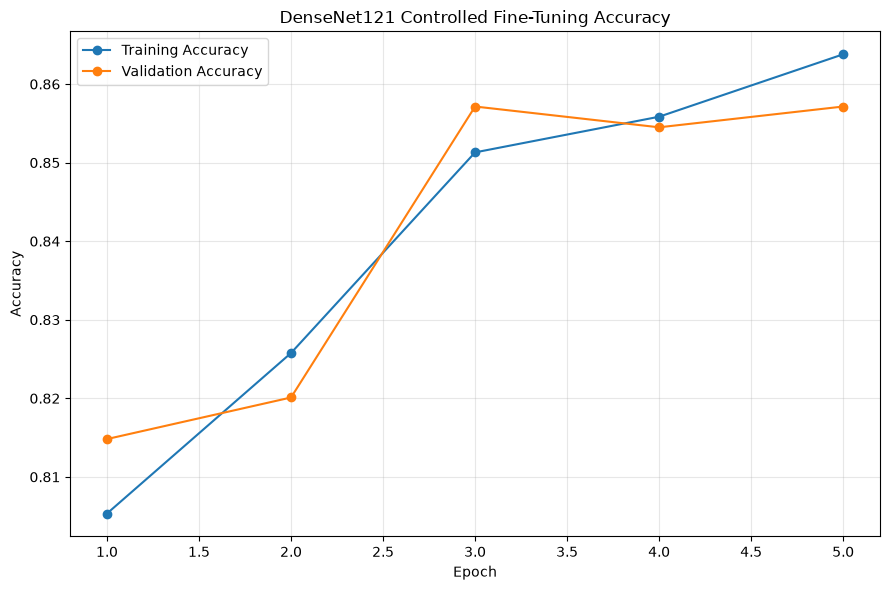

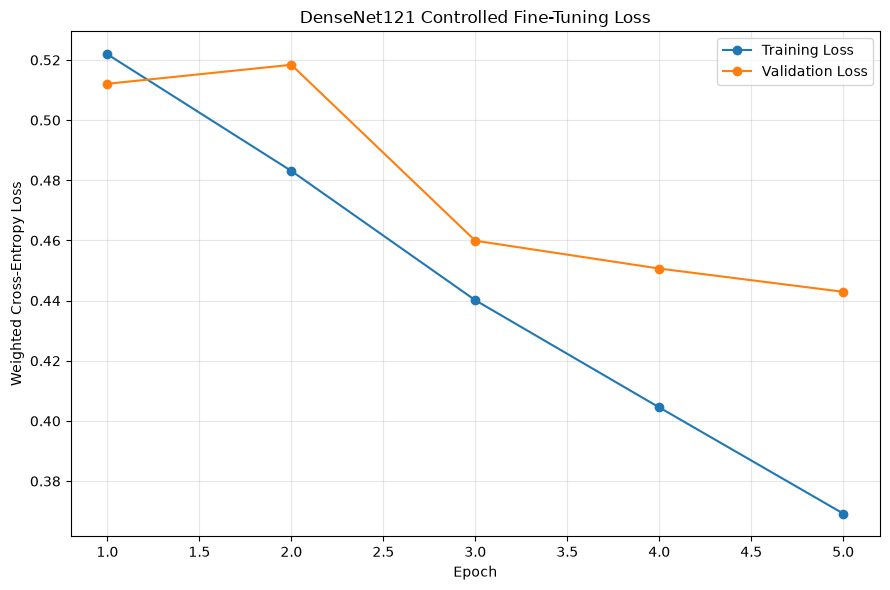

In [53]:
(
    FINE_TUNING_ACCURACY_FIGURE_PATH,
    FINE_TUNING_LOSS_FIGURE_PATH,
) = plot_training_curves(
    history=fine_tuning_history,
    title_prefix=(
        "DenseNet121 Controlled Fine-Tuning"
    ),
    file_prefix=(
        "densenet121_fine_tuning"
    ),
)

In [55]:
best_fine_tuning_row = (
    fine_tuning_history.loc[
        fine_tuning_history[
            "validation_loss"
        ].idxmin()
    ]
)

best_fine_tuning_epoch = int(
    best_fine_tuning_row["epoch"]
)

best_fine_tuning_validation_loss = float(
    best_fine_tuning_row[
        "validation_loss"
    ]
)

best_fine_tuning_validation_accuracy = float(
    best_fine_tuning_row[
        "validation_accuracy"
    ]
)

validation_comparison = pd.DataFrame(
    [
        {
            "training_stage": (
                "Frozen feature extraction"
            ),
            "best_epoch": best_frozen_epoch,
            "validation_loss": (
                best_frozen_validation_loss
            ),
            "validation_accuracy": (
                best_frozen_validation_accuracy
            ),
        },
        {
            "training_stage": (
                "Controlled fine-tuning"
            ),
            "best_epoch": (
                best_fine_tuning_epoch
            ),
            "validation_loss": (
                best_fine_tuning_validation_loss
            ),
            "validation_accuracy": (
                best_fine_tuning_validation_accuracy
            ),
        },
    ]
)

validation_comparison

,training_stage,best_epoch,validation_loss,validation_accuracy
0,Frozen feature extraction,10,0.578359,0.830688
1,Controlled fine-tuning,5,0.442937,0.857143


In [56]:
validation_accuracy_change = (
    best_fine_tuning_validation_accuracy
    - best_frozen_validation_accuracy
)

validation_loss_change = (
    best_fine_tuning_validation_loss
    - best_frozen_validation_loss
)

print(
    f"Validation accuracy change: "
    f"{validation_accuracy_change:+.4f}"
)

print(
    f"Validation loss change: "
    f"{validation_loss_change:+.4f}"
)

Validation accuracy change: +0.0265
Validation loss change: -0.1354


In [57]:
def build_densenet121_model(
    number_of_classes: int,
    dropout_rate: float,
    device: torch.device,
) -> nn.Module:
    """
    Construct DenseNet121 with the project classifier.
    """
    model = densenet121(
        weights=None
    )

    classifier_input_features = (
        model.classifier.in_features
    )

    model.classifier = nn.Sequential(
        nn.Dropout(
            p=dropout_rate
        ),
        nn.Linear(
            classifier_input_features,
            number_of_classes,
        ),
    )

    return model.to(device)

In [58]:
final_densenet_model = (
    build_densenet121_model(
        number_of_classes=NUM_CLASSES,
        dropout_rate=DROPOUT_RATE,
        device=DEVICE,
    )
)

final_checkpoint = torch.load(
    FINE_TUNED_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

final_densenet_model.load_state_dict(
    final_checkpoint[
        "model_state_dict"
    ]
)

final_densenet_model.eval()

print(
    "Best fine-tuned DenseNet121 checkpoint loaded."
)

Best fine-tuned DenseNet121 checkpoint loaded.


In [59]:
if (
    final_checkpoint["class_names"]
    != class_names
):
    raise ValueError(
        "Checkpoint class names do not match."
    )

if (
    final_checkpoint["class_to_index"]
    != class_to_index
):
    raise ValueError(
        "Checkpoint class mapping does not match."
    )

if tuple(
    final_checkpoint["image_size"]
) != tuple(IMAGE_SIZE):
    raise ValueError(
        "Checkpoint image size does not match."
    )

print(
    "DenseNet121 checkpoint metadata verified."
)

DenseNet121 checkpoint metadata verified.


In [60]:
def collect_predictions(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict:
    """
    Evaluate the complete test set and collect predictions.
    """
    model.eval()

    running_loss = 0.0
    sample_count = 0

    true_labels = []
    predicted_labels = []
    probability_batches = []
    image_paths = []

    start_time = time.perf_counter()

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = torch.argmax(
                probabilities,
                dim=1,
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            sample_count += batch_size

            true_labels.extend(
                labels.cpu().tolist()
            )

            predicted_labels.extend(
                predictions.cpu().tolist()
            )

            probability_batches.append(
                probabilities.cpu().numpy()
            )

            image_paths.extend(
                list(batch["path"])
            )

    duration_seconds = (
        time.perf_counter()
        - start_time
    )

    return {
        "loss": float(
            running_loss / sample_count
        ),
        "true_labels": np.asarray(
            true_labels,
            dtype=np.int64,
        ),
        "predicted_labels": np.asarray(
            predicted_labels,
            dtype=np.int64,
        ),
        "probabilities": np.concatenate(
            probability_batches,
            axis=0,
        ),
        "image_paths": image_paths,
        "duration_seconds": float(
            duration_seconds
        ),
    }

In [61]:
final_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

test_output = collect_predictions(
    model=final_densenet_model,
    data_loader=test_loader,
    loss_function=final_criterion,
    device=DEVICE,
)

test_loss = test_output["loss"]
true_labels = test_output["true_labels"]
predicted_labels = (
    test_output["predicted_labels"]
)
prediction_probabilities = (
    test_output["probabilities"]
)
test_image_paths = (
    test_output["image_paths"]
)

print(
    f"Test samples: {len(true_labels)}"
)

print(
    f"Test loss: {test_loss:.4f}"
)

Test samples: 381
Test loss: 0.4338


In [62]:
test_accuracy = accuracy_score(
    true_labels,
    predicted_labels,
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _,
) = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
    average="weighted",
    zero_division=0,
)

(
    macro_precision,
    macro_recall,
    macro_f1,
    _,
) = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
    average="macro",
    zero_division=0,
)

print("=" * 70)
print("DENSENET121 TEST METRICS")
print("=" * 70)
print(f"Test loss          : {test_loss:.4f}")
print(f"Test accuracy      : {test_accuracy:.4f}")
print(f"Weighted precision : {weighted_precision:.4f}")
print(f"Weighted recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")
print(f"Macro precision    : {macro_precision:.4f}")
print(f"Macro recall       : {macro_recall:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")

DENSENET121 TEST METRICS
Test loss          : 0.4338
Test accuracy      : 0.8294
Weighted precision : 0.8385
Weighted recall    : 0.8294
Weighted F1-score  : 0.8305
Macro precision    : 0.8078
Macro recall       : 0.8318
Macro F1-score     : 0.8151


In [63]:
classification_report_dictionary = (
    classification_report(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
)

classification_report_dataframe = (
    pd.DataFrame(
        classification_report_dictionary
    ).transpose()
)

classification_report_dataframe

,precision,recall,f1-score,support
cardboard,0.800000,0.852459,0.825397,61.000000
glass,0.935484,0.773333,0.846715,75.000000
metal,0.814286,0.919355,0.863636,62.000000
paper,0.865854,0.788889,0.825581,90.000000
plastic,0.824324,0.847222,0.835616,72.000000
trash,0.607143,0.809524,0.693878,21.000000
accuracy,0.829396,0.829396,0.829396,0.829396
macro avg,0.807848,0.831797,0.815137,381.000000
weighted avg,0.838518,0.829396,0.830542,381.000000


In [86]:
CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_classification_report.csv"
)

classification_report_dataframe.to_csv(
    CLASSIFICATION_REPORT_PATH,
    index=True,
)

print(
    "Classification report saved to:"
)

print(
    CLASSIFICATION_REPORT_PATH.resolve()
)

print(
    "File exists:",
    CLASSIFICATION_REPORT_PATH.exists(),
)

Classification report saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\densenet121_classification_report.csv
File exists: True


In [64]:
true_labels_one_hot = (
    np.eye(NUM_CLASSES)[true_labels]
)

macro_roc_auc = None
weighted_roc_auc = None

try:
    macro_roc_auc = roc_auc_score(
        true_labels_one_hot,
        prediction_probabilities,
        multi_class="ovr",
        average="macro",
    )

    weighted_roc_auc = roc_auc_score(
        true_labels_one_hot,
        prediction_probabilities,
        multi_class="ovr",
        average="weighted",
    )

    print(
        f"Macro ROC-AUC: "
        f"{macro_roc_auc:.4f}"
    )

    print(
        f"Weighted ROC-AUC: "
        f"{weighted_roc_auc:.4f}"
    )

except ValueError as error:
    print(
        "ROC-AUC could not be calculated:"
    )
    print(error)

Macro ROC-AUC: 0.9820
Weighted ROC-AUC: 0.9812


In [65]:
confusion_matrix_values = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
)

confusion_matrix_dataframe = pd.DataFrame(
    confusion_matrix_values,
    index=class_names,
    columns=class_names,
)

CONFUSION_MATRIX_CSV_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_confusion_matrix.csv"
)

confusion_matrix_dataframe.to_csv(
    CONFUSION_MATRIX_CSV_PATH
)

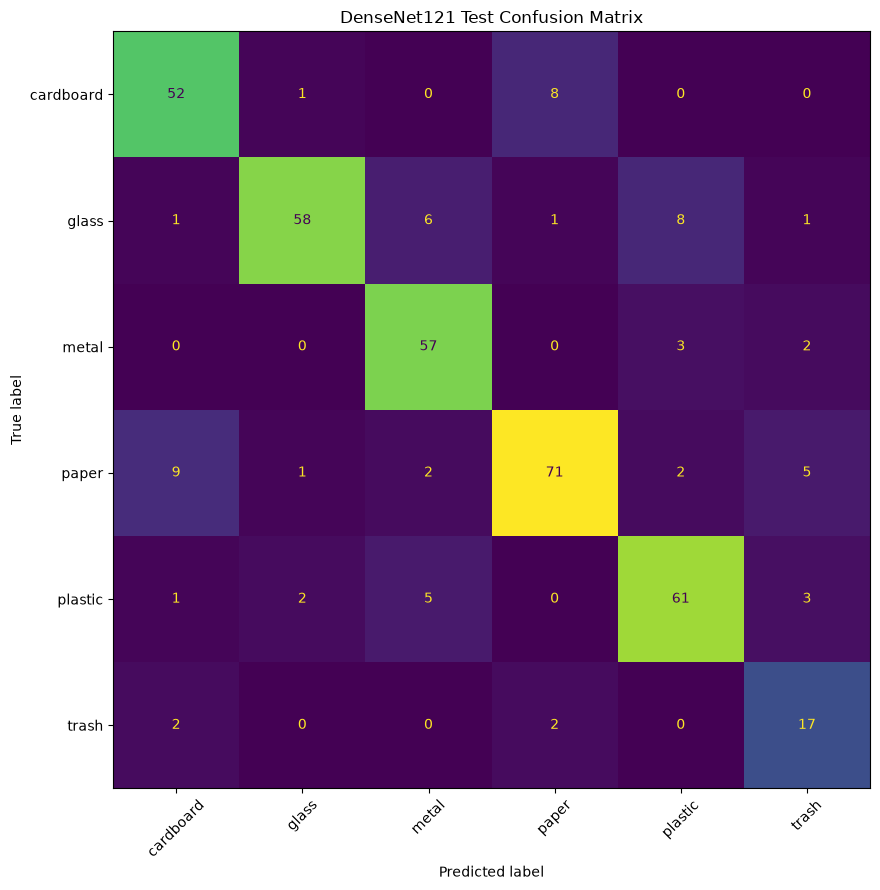

In [66]:
figure, axis = plt.subplots(
    figsize=(10, 9)
)

ConfusionMatrixDisplay(
    confusion_matrix=(
        confusion_matrix_values
    ),
    display_labels=class_names,
).plot(
    ax=axis,
    values_format="d",
    xticks_rotation=45,
    colorbar=False,
)

plt.title(
    "DenseNet121 Test Confusion Matrix"
)

plt.tight_layout()

CONFUSION_MATRIX_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "densenet121_test_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [67]:
class_test_counts = (
    confusion_matrix_values.sum(axis=1)
)

class_correct_counts = (
    np.diag(confusion_matrix_values)
)

per_class_accuracy = np.divide(
    class_correct_counts,
    class_test_counts,
    out=np.zeros_like(
        class_correct_counts,
        dtype=float,
    ),
    where=class_test_counts != 0,
)

per_class_results = pd.DataFrame(
    {
        "class_name": class_names,
        "test_samples": class_test_counts,
        "correct_predictions": (
            class_correct_counts
        ),
        "per_class_accuracy": (
            per_class_accuracy
        ),
        "precision": [
            classification_report_dictionary[
                class_name
            ]["precision"]
            for class_name in class_names
        ],
        "recall": [
            classification_report_dictionary[
                class_name
            ]["recall"]
            for class_name in class_names
        ],
        "f1_score": [
            classification_report_dictionary[
                class_name
            ]["f1-score"]
            for class_name in class_names
        ],
    }
)

per_class_results

,class_name,test_samples,correct_predictions,per_class_accuracy,precision,recall,f1_score
0,cardboard,61,52,0.852459,0.800000,0.852459,0.825397
1,glass,75,58,0.773333,0.935484,0.773333,0.846715
2,metal,62,57,0.919355,0.814286,0.919355,0.863636
3,paper,90,71,0.788889,0.865854,0.788889,0.825581
4,plastic,72,61,0.847222,0.824324,0.847222,0.835616
5,trash,21,17,0.809524,0.607143,0.809524,0.693878


In [68]:
PER_CLASS_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_per_class_results.csv"
)

per_class_results.to_csv(
    PER_CLASS_RESULTS_PATH,
    index=False,
)

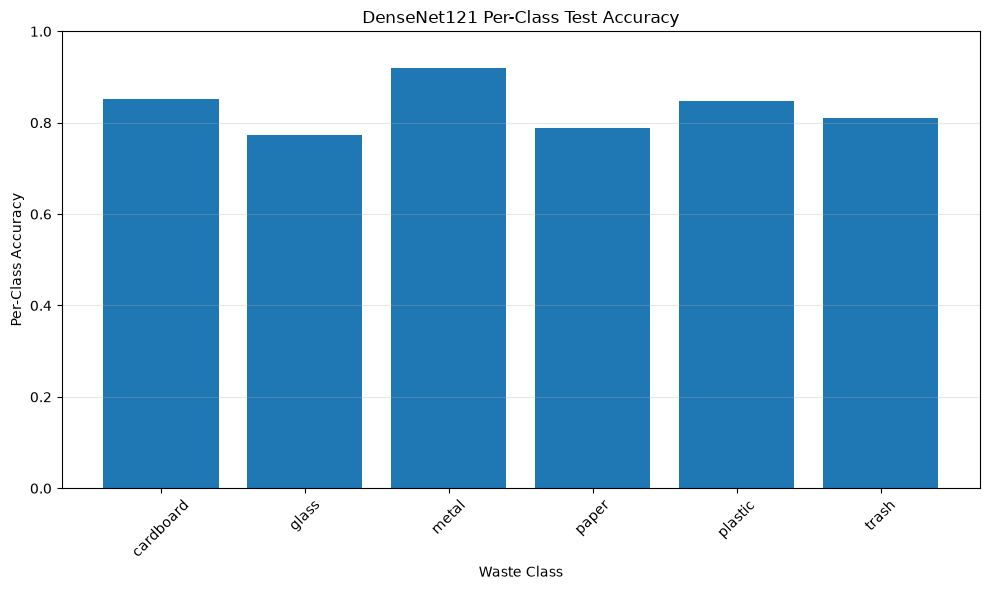

In [69]:
plt.figure(figsize=(10, 6))

plt.bar(
    per_class_results["class_name"],
    per_class_results[
        "per_class_accuracy"
    ],
)

plt.ylim(0, 1)
plt.xlabel("Waste Class")
plt.ylabel("Per-Class Accuracy")
plt.title(
    "DenseNet121 Per-Class Test Accuracy"
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

PER_CLASS_ACCURACY_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "densenet121_per_class_accuracy.png"
)

plt.savefig(
    PER_CLASS_ACCURACY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [70]:
prediction_confidences = (
    prediction_probabilities.max(axis=1)
)

prediction_results = pd.DataFrame(
    {
        "image_path": test_image_paths,
        "true_class": [
            index_to_class[int(label)]
            for label in true_labels
        ],
        "predicted_class": [
            index_to_class[int(label)]
            for label in predicted_labels
        ],
        "confidence": prediction_confidences,
        "correct": (
            true_labels == predicted_labels
        ),
    }
)

for class_index, class_name in enumerate(
    class_names
):
    prediction_results[
        f"probability_{class_name}"
    ] = prediction_probabilities[
        :,
        class_index,
    ]

PREDICTION_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_test_predictions.csv"
)

prediction_results.to_csv(
    PREDICTION_RESULTS_PATH,
    index=False,
)

In [71]:
incorrect_predictions = (
    prediction_results[
        prediction_results["correct"] == False
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

correct_predictions = (
    prediction_results[
        prediction_results["correct"] == True
    ]
    .sort_values(
        "confidence",
        ascending=True,
    )
    .reset_index(drop=True)
)

highest_confidence_errors = (
    incorrect_predictions.head(20)
)

HIGH_CONFIDENCE_ERRORS_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_high_confidence_errors.csv"
)

highest_confidence_errors.to_csv(
    HIGH_CONFIDENCE_ERRORS_PATH,
    index=False,
)

In [72]:
confusion_records = []

for true_index in range(NUM_CLASSES):
    for predicted_index in range(
        NUM_CLASSES
    ):
        if true_index == predicted_index:
            continue

        confusion_records.append(
            {
                "true_class": class_names[
                    true_index
                ],
                "predicted_class": (
                    class_names[
                        predicted_index
                    ]
                ),
                "error_count": int(
                    confusion_matrix_values[
                        true_index,
                        predicted_index,
                    ]
                ),
            }
        )

class_confusions = (
    pd.DataFrame(
        confusion_records
    )
    .sort_values(
        "error_count",
        ascending=False,
    )
    .reset_index(drop=True)
)

CLASS_CONFUSIONS_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_class_confusions.csv"
)

class_confusions.to_csv(
    CLASS_CONFUSIONS_PATH,
    index=False,
)

class_confusions.head(10)

,true_class,predicted_class,error_count
0,paper,cardboard,9
1,cardboard,paper,8
2,glass,plastic,8
3,glass,metal,6
4,paper,trash,5
5,plastic,metal,5
6,plastic,trash,3
7,metal,plastic,3
8,paper,plastic,2
9,plastic,glass,2


In [73]:
confidence_summary = (
    prediction_results
    .groupby("correct")["confidence"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
            "std",
        ]
    )
)

confidence_summary

,count,mean,median,min,max,std
correct,,,,,,
False,65,0.631617,0.610732,0.338984,0.957784,0.169503
True,316,0.888739,0.958070,0.254738,0.999831,0.145839


In [74]:
true_distribution = (
    prediction_results["true_class"]
    .value_counts()
    .reindex(
        class_names,
        fill_value=0,
    )
)

predicted_distribution = (
    prediction_results[
        "predicted_class"
    ]
    .value_counts()
    .reindex(
        class_names,
        fill_value=0,
    )
)

distribution_comparison = pd.DataFrame(
    {
        "true_count": true_distribution,
        "predicted_count": (
            predicted_distribution
        ),
    }
)

DISTRIBUTION_COMPARISON_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_prediction_distribution.csv"
)

distribution_comparison.to_csv(
    DISTRIBUTION_COMPARISON_PATH
)

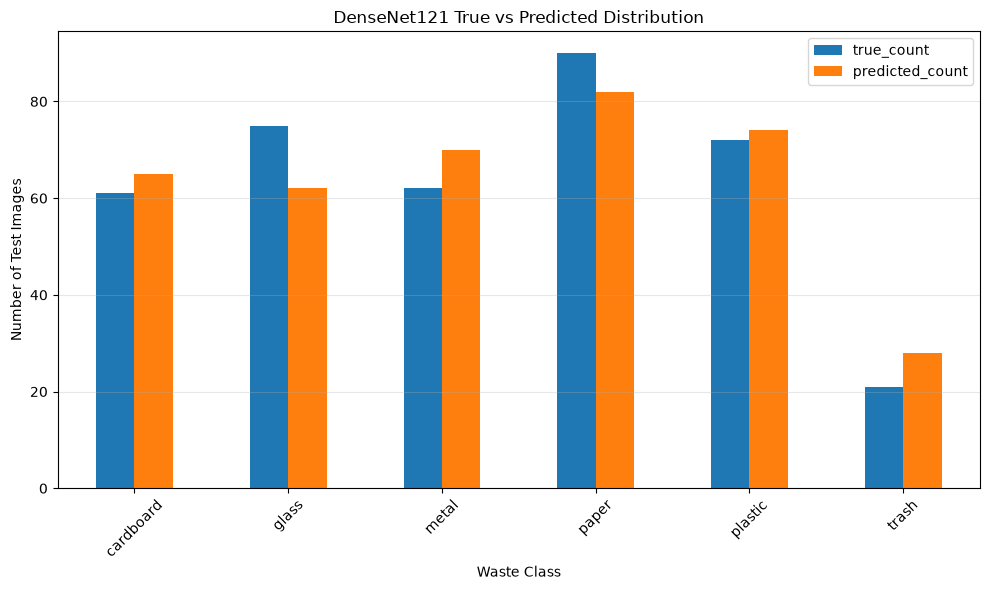

In [75]:
distribution_comparison.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.xlabel("Waste Class")
plt.ylabel("Number of Test Images")
plt.title(
    "DenseNet121 True vs Predicted Distribution"
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

PREDICTION_DISTRIBUTION_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "densenet121_prediction_distribution.png"
)

plt.savefig(
    PREDICTION_DISTRIBUTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [95]:
DEPLOYMENT_MODEL_PATH = (
    MODEL_DIRECTORY
    / "densenet121_deployment.pt"
)

deployment_package = {
    "architecture": "densenet121",
    "model_version": MODEL_VERSION,
    "model_state_dict": (
        final_densenet_model.state_dict()
    ),
    "class_names": list(class_names),
    "class_to_index": dict(
        class_to_index
    ),
    "number_of_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "normalization_mean": (
        IMAGENET_MEAN
    ),
    "normalization_std": (
        IMAGENET_STANDARD_DEVIATION
    ),
    "dropout_rate": DROPOUT_RATE,
    "saved_at": datetime.now().isoformat(),
}

torch.save(
    deployment_package,
    DEPLOYMENT_MODEL_PATH,
)

model_size_mb = (
    DEPLOYMENT_MODEL_PATH.stat().st_size
    / (1024 ** 2)
)

training_checkpoint_size_mb = (
    FINE_TUNED_CHECKPOINT_PATH.stat().st_size
    / (1024 ** 2)
)

print(
    f"Inference-only model size: "
    f"{model_size_mb:.2f} MB"
)

print(
    f"Training checkpoint size: "
    f"{training_checkpoint_size_mb:.2f} MB"
)

print(
    "Deployment package saved to:"
)

print(
    DEPLOYMENT_MODEL_PATH.resolve()
)

Inference-only model size: 27.13 MB
Training checkpoint size: 43.46 MB
Deployment package saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\densenet121_deployment.pt


In [77]:
latency_batch = next(
    iter(test_loader)
)

latency_image = (
    latency_batch["image"][:1]
    .to(DEVICE)
)

WARM_UP_RUNS = 5
LATENCY_RUNS = 100

with torch.inference_mode():
    for _ in range(WARM_UP_RUNS):
        _ = final_densenet_model(
            latency_image
        )

latency_measurements_ms = []

with torch.inference_mode():
    for _ in range(LATENCY_RUNS):
        start_time = time.perf_counter()

        _ = final_densenet_model(
            latency_image
        )

        end_time = time.perf_counter()

        latency_measurements_ms.append(
            (
                end_time - start_time
            )
            * 1000
        )

mean_latency_ms = float(
    np.mean(latency_measurements_ms)
)

median_latency_ms = float(
    np.median(latency_measurements_ms)
)

latency_95th_percentile_ms = float(
    np.percentile(
        latency_measurements_ms,
        95,
    )
)

predictions_per_second = (
    1000 / mean_latency_ms
)

print(
    f"Mean latency: "
    f"{mean_latency_ms:.2f} ms"
)

print(
    f"Median latency: "
    f"{median_latency_ms:.2f} ms"
)

print(
    f"95th percentile: "
    f"{latency_95th_percentile_ms:.2f} ms"
)

print(
    f"Throughput: "
    f"{predictions_per_second:.2f} predictions/second"
)

Mean latency: 159.79 ms
Median latency: 151.44 ms
95th percentile: 239.83 ms
Throughput: 6.26 predictions/second


In [78]:
strongest_class_record = (
    per_class_results.loc[
        per_class_results[
            "per_class_accuracy"
        ].idxmax()
    ]
)

weakest_class_record = (
    per_class_results.loc[
        per_class_results[
            "per_class_accuracy"
        ].idxmin()
    ]
)

non_zero_confusions = (
    class_confusions[
        class_confusions[
            "error_count"
        ] > 0
    ]
)

most_frequent_confusion = (
    non_zero_confusions.iloc[0]
    if not non_zero_confusions.empty
    else None
)

In [79]:
final_parameter_summary = (
    count_model_parameters(
        final_densenet_model
    )
)

densenet_final_results = {
    "experiment_name": EXPERIMENT_NAME,
    "architecture": "densenet121",
    "model_version": MODEL_VERSION,
    "device": str(DEVICE),

    "dataset": {
        "training_images": len(
            train_dataset
        ),
        "validation_images": len(
            validation_dataset
        ),
        "test_images": len(
            test_dataset
        ),
        "class_names": class_names,
        "image_size": list(IMAGE_SIZE),
    },

    "frozen_stage": {
        "best_epoch": best_frozen_epoch,
        "validation_loss": (
            best_frozen_validation_loss
        ),
        "validation_accuracy": (
            best_frozen_validation_accuracy
        ),
    },

    "fine_tuning_stage": {
        "trainable_backbone_section": (
            "denseblock4"
        ),
        "batch_normalization_frozen": True,
        "backbone_learning_rate": (
            BACKBONE_FINE_TUNE_LEARNING_RATE
        ),
        "classifier_learning_rate": (
            CLASSIFIER_FINE_TUNE_LEARNING_RATE
        ),
        "best_epoch": (
            best_fine_tuning_epoch
        ),
        "validation_loss": (
            best_fine_tuning_validation_loss
        ),
        "validation_accuracy": (
            best_fine_tuning_validation_accuracy
        ),
    },

    "test_metrics": {
        "loss": float(test_loss),
        "accuracy": float(
            test_accuracy
        ),
        "weighted_precision": float(
            weighted_precision
        ),
        "weighted_recall": float(
            weighted_recall
        ),
        "weighted_f1": float(
            weighted_f1
        ),
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1": float(
            macro_f1
        ),
        "macro_roc_auc": (
            float(macro_roc_auc)
            if macro_roc_auc is not None
            else None
        ),
        "weighted_roc_auc": (
            float(weighted_roc_auc)
            if weighted_roc_auc
            is not None
            else None
        ),
    },

    "class_analysis": {
        "strongest_class": str(
            strongest_class_record[
                "class_name"
            ]
        ),
        "weakest_class": str(
            weakest_class_record[
                "class_name"
            ]
        ),
        "most_frequent_confusion": (
            {
                "true_class": str(
                    most_frequent_confusion[
                        "true_class"
                    ]
                ),
                "predicted_class": str(
                    most_frequent_confusion[
                        "predicted_class"
                    ]
                ),
                "count": int(
                    most_frequent_confusion[
                        "error_count"
                    ]
                ),
            }
            if most_frequent_confusion
            is not None
            else None
        ),
    },

    "deployment_metrics": {
        "checkpoint_size_mb": float(
            model_size_mb
        ),
        "total_parameters": int(
            final_parameter_summary[
                "total_parameters"
            ]
        ),
        "mean_latency_ms": float(
            mean_latency_ms
        ),
        "median_latency_ms": float(
            median_latency_ms
        ),
        "latency_95th_percentile_ms": float(
            latency_95th_percentile_ms
        ),
        "predictions_per_second": float(
            predictions_per_second
        ),
    },
}

In [80]:
FINAL_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_final_results.json"
)

with open(
    FINAL_RESULTS_PATH,
    "w",
    encoding="utf-8",
) as results_file:
    json.dump(
        densenet_final_results,
        results_file,
        indent=4,
    )

print(FINAL_RESULTS_PATH.resolve())

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\densenet121_final_results.json


## Model Comparison Row

In [81]:
densenet_comparison_row = pd.DataFrame(
    [
        {
            "model_name": "DenseNet121",
            "architecture": "densenet121",
            "test_loss": test_loss,
            "test_accuracy": (
                test_accuracy
            ),
            "weighted_precision": (
                weighted_precision
            ),
            "weighted_recall": (
                weighted_recall
            ),
            "weighted_f1_score": (
                weighted_f1
            ),
            "macro_f1_score": (
                macro_f1
            ),
            "macro_roc_auc": (
                macro_roc_auc
            ),
            "model_size_mb": (
                model_size_mb
            ),
            "total_parameters": (
                final_parameter_summary[
                    "total_parameters"
                ]
            ),
            "mean_inference_latency_ms": (
                mean_latency_ms
            ),
            "median_inference_latency_ms": (
                median_latency_ms
            ),
            "predictions_per_second": (
                predictions_per_second
            ),
            "best_validation_accuracy": (
                best_fine_tuning_validation_accuracy
            ),
            "best_validation_loss": (
                best_fine_tuning_validation_loss
            ),
        }
    ]
)

DENSENET_COMPARISON_ROW_PATH = (
    RESULTS_DIRECTORY
    / "densenet121_comparison_row.csv"
)

densenet_comparison_row.to_csv(
    DENSENET_COMPARISON_ROW_PATH,
    index=False,
)

densenet_comparison_row

,model_name,architecture,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_f1_score,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,median_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss
0,DenseNet121,densenet121,0.433801,0.829396,0.838518,0.829396,0.830542,0.815137,0.981981,43.458006,6960006,159.790327,151.44305,6.258201,0.857143,0.442937


## Artifact Verification 

In [93]:
expected_artifacts = [
    FROZEN_CHECKPOINT_PATH,
    FINE_TUNED_CHECKPOINT_PATH,
    FROZEN_HISTORY_PATH,
    FINE_TUNING_HISTORY_PATH,
    FROZEN_ACCURACY_FIGURE_PATH,
    FROZEN_LOSS_FIGURE_PATH,
    FINE_TUNING_ACCURACY_FIGURE_PATH,
    FINE_TUNING_LOSS_FIGURE_PATH,
    CLASSIFICATION_REPORT_PATH,
    CONFUSION_MATRIX_CSV_PATH,
    CONFUSION_MATRIX_FIGURE_PATH,
    PER_CLASS_RESULTS_PATH,
    PER_CLASS_ACCURACY_FIGURE_PATH,
    PREDICTION_RESULTS_PATH,
    HIGH_CONFIDENCE_ERRORS_PATH,
    CLASS_CONFUSIONS_PATH,
    DISTRIBUTION_COMPARISON_PATH,
    PREDICTION_DISTRIBUTION_FIGURE_PATH,
    FINAL_RESULTS_PATH,
    DENSENET_COMPARISON_ROW_PATH,
]

artifact_verification = pd.DataFrame(
    [
        {
            "artifact": str(path),
            "exists": path.exists(),
            "size_kb": (
                path.stat().st_size / 1024
                if path.exists()
                else None
            ),
        }
        for path in expected_artifacts
    ]
)

artifact_verification


,artifact,exists,size_kb
0,..\models\densenet121_frozen_best.pt,True,27830.801758
1,..\models\densenet121_finetuned_best.pt,True,44500.998047
2,..\logs\densenet121_frozen_history.csv,True,1.243164
3,..\logs\densenet121_fine_tuning_history.csv,True,0.754883
4,..\results\figures\densenet121_frozen_accuracy...,True,166.482422
5,..\results\figures\densenet121_frozen_loss.png,True,167.633789
6,..\results\figures\densenet121_fine_tuning_acc...,True,159.712891
7,..\results\figures\densenet121_fine_tuning_los...,True,175.610352
8,..\results\densenet121_classification_report.csv,True,0.661133
9,..\results\densenet121_confusion_matrix.csv,True,0.166016


In [94]:
missing_artifacts = (
    artifact_verification[
        artifact_verification[
            "exists"
        ] == False
    ]
)

if not missing_artifacts.empty:
    display(missing_artifacts)

    raise FileNotFoundError(
        "One or more DenseNet121 artifacts "
        "were not created."
    )

print(
    "All expected DenseNet121 artifacts "
    "were created successfully."
)

All expected DenseNet121 artifacts were created successfully.


#  DenseNet121 Completion Checklist

- [x] Same split manifest reused
- [x] Data leakage checked
- [x] Same preprocessing and augmentation reused
- [x] Class imbalance handled
- [x] ImageNet-pretrained DenseNet121 loaded
- [x] Six-class classifier added
- [x] Frozen feature extraction completed
- [x] Controlled fine-tuning completed
- [x] Batch Normalization strategy documented
- [x] Differential learning rates documented
- [x] Early stopping and scheduling applied
- [x] Learning curves generated
- [x] Accuracy calculated
- [x] Precision calculated
- [x] Recall calculated
- [x] F1-score calculated
- [x] ROC-AUC calculated
- [x] Confusion matrix generated
- [x] Per-class accuracy calculated
- [x] Error analysis completed
- [x] Model size measured
- [x] Inference latency measured
- [x] Final checkpoint saved
- [x] Structured result files saved
- [x] Model-comparison row created
- [x] Artifacts verified

The DenseNet121 experiment is complete.

# DenseNet121 Final Experiment Conclusion

DenseNet121 was successfully implemented and evaluated using a two-stage
transfer-learning strategy.

## Frozen feature extraction

During the initial stage, the complete ImageNet-pretrained DenseNet121 feature
extractor remained frozen. Only the newly added six-class TrashNet classifier
was optimized.

The frozen-stage model achieved its best result at epoch **10**:

- Validation loss: **0.5784**
- Validation accuracy: **0.8307**

The consistent improvement in validation loss across the frozen stage indicates
that the pretrained DenseNet features transferred effectively to the TrashNet
classification problem.

## Controlled fine-tuning

During fine-tuning, `denseblock4` and the custom classifier were selected for
optimization. Earlier DenseNet blocks remained frozen, and Batch Normalization
parameters and running statistics were preserved.

Differential learning rates were applied:

- DenseNet backbone: **0.00001**
- Classification head: **0.0001**

The best fine-tuned checkpoint was recorded at epoch **5**:

- Validation loss: **0.4429**
- Validation accuracy: **0.8571**

Compared with frozen feature extraction, fine-tuning:

- Improved validation accuracy by approximately **2.65 percentage points**
- Reduced validation loss by approximately **0.1354**

This indicates that controlled adaptation of the final DenseNet block improved
generalization without producing a large training-validation performance gap.

## Test-set performance

The final fine-tuned DenseNet121 model achieved:

| Metric | Result |
|---|---:|
| Test loss | **0.4338** |
| Test accuracy | **0.8294** |
| Weighted precision | **0.8385** |
| Weighted recall | **0.8294** |
| Weighted F1-score | **0.8305** |
| Macro precision | **0.8078** |
| Macro recall | **0.8318** |
| Macro F1-score | **0.8151** |
| Macro ROC-AUC | **0.9820** |
| Weighted ROC-AUC | **0.9812** |
| Mean CPU inference latency | **159.79 ms** |
| Median CPU inference latency | **151.44 ms** |
| Approximate throughput | **6.26 predictions/second** |

The high ROC-AUC score indicates that DenseNet121 generally separates the six
waste categories well across classification thresholds. The lower macro F1
relative to weighted F1 suggests that performance is not completely uniform
across all classes, particularly for classes with fewer samples.

## Deployment position

DenseNet121 provides strong predictive performance but must still be compared
with the baseline CNN, ResNet50, EfficientNet-B0, and MobileNetV3 using the same
test split and hardware.

The final deployment model will be selected using a combination of:

- Predictive performance
- Per-class behavior
- Error severity
- Model size
- Inference latency
- Deployment practicality

No final model-selection decision is made in this notebook.